#### Librerias

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from scipy import sparse
import joblib
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Variables

In [ ]:
MODELOS_PATH = "/content/drive/MyDrive/Trabajo práctico 3/modelos"

#### Carga de datos y modelos

In [ ]:
df_test = pd.read_pickle(f"{MODELOS_PATH}/test_con_textblob.pkl")
df_train = pd.read_pickle(f"{MODELOS_PATH}/train_limpio.pkl")

X_test_bow = sparse.load_npz(f"{MODELOS_PATH}/X_test_bow.npz")
X_test_tfidf = sparse.load_npz(f"{MODELOS_PATH}/X_test_tfidf.npz")
X_train_tfidf = sparse.load_npz(f"{MODELOS_PATH}/X_train_tfidf.npz")

modelo_nb = joblib.load(f"{MODELOS_PATH}/modelo_nb_optimizado.pkl")
modelo_lr = joblib.load(f"{MODELOS_PATH}/modelo_lr_optimizado.pkl")

X_train_bow = sparse.load_npz(f"{MODELOS_PATH}/X_train_bow.npz")
y_train = np.load(f"{MODELOS_PATH}/y_train.npy")

#### Subset binario y predicciones de los 3 métodos

In [ ]:
mask_binario = df_test["polarity"].values != 2

X_test_bow_bin = X_test_bow[mask_binario]
X_test_tfidf_bin = X_test_tfidf[mask_binario]
y_test_bin = df_test["polarity"].values[mask_binario]

df_test_bin = df_test[mask_binario].reset_index(drop=True)

pred_nb_bin = modelo_nb.predict(X_test_bow_bin)
pred_lr_bin = modelo_lr.predict(X_test_tfidf_bin)
pred_textblob_bin = df_test_bin["pred_textblob"].values

#### Tabla resumen de métricas finales

In [ ]:
def resumen_metricas(y_true, y_pred, nombre):
    reporte = classification_report(y_true, y_pred, labels=[0, 4], output_dict=True)
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": reporte["weighted avg"]["precision"],
        "recall": reporte["weighted avg"]["recall"],
        "f1-score": reporte["weighted avg"]["f1-score"],
    }

tabla_final = pd.DataFrame([
    resumen_metricas(y_test_bin, pred_nb_bin, "Naive Bayes (BoW)"),
    resumen_metricas(y_test_bin, pred_lr_bin, "Logistic Regression (TF-IDF)"),
    resumen_metricas(y_test_bin, pred_textblob_bin, "TextBlob (pre-entrenado)"),
])

tabla_final

,modelo,accuracy,precision,recall,f1-score
0,Naive Bayes (BoW),0.832869,0.832936,0.832869,0.832877
1,Logistic Regression (TF-IDF),0.818942,0.818988,0.818942,0.818908
2,TextBlob (pre-entrenado),0.640669,0.792712,0.640669,0.690370


La tabla confirma el orden final: NB (0.83) apenas arriba de LR (0.82), y TextBlob
bastante más abajo (0.64). Nótese que TextBlob mantiene precision alta (0.79) pese
a su accuracy bajo — la explicación está en la celda siguiente.

#### Evaluación completa: train vs test

In [ ]:
pred_nb_train = modelo_nb.predict(X_train_bow)
pred_lr_train = modelo_lr.predict(X_train_tfidf)

print("=== NAIVE BAYES ===")
print("TRAIN:")
print(classification_report(y_train, pred_nb_train, labels=[0,4], target_names=["Negativo","Positivo"]))
print("TEST:")
print(classification_report(y_test_bin, pred_nb_bin, labels=[0,4], target_names=["Negativo","Positivo"]))

print("\n=== LOGISTIC REGRESSION ===")
print("TRAIN:")
print(classification_report(y_train, pred_lr_train, labels=[0,4], target_names=["Negativo","Positivo"]))
print("TEST:")
print(classification_report(y_test_bin, pred_lr_bin, labels=[0,4], target_names=["Negativo","Positivo"]))

=== NAIVE BAYES ===
TRAIN:
              precision    recall  f1-score   support

    Negativo       0.77      0.78      0.78    800000
    Positivo       0.78      0.76      0.77    800000

    accuracy                           0.77   1600000
   macro avg       0.77      0.77      0.77   1600000
weighted avg       0.77      0.77      0.77   1600000

TEST:
              precision    recall  f1-score   support

    Negativo       0.83      0.84      0.83       177
    Positivo       0.84      0.83      0.83       182

    accuracy                           0.83       359
   macro avg       0.83      0.83      0.83       359
weighted avg       0.83      0.83      0.83       359


=== LOGISTIC REGRESSION ===
TRAIN:
              precision    recall  f1-score   support

    Negativo       0.80      0.77      0.78    800000
    Positivo       0.78      0.81      0.79    800000

    accuracy                           0.79   1600000
   macro avg       0.79      0.79      0.79   1600000
weigh

#### Matrices de confusión — train vs test

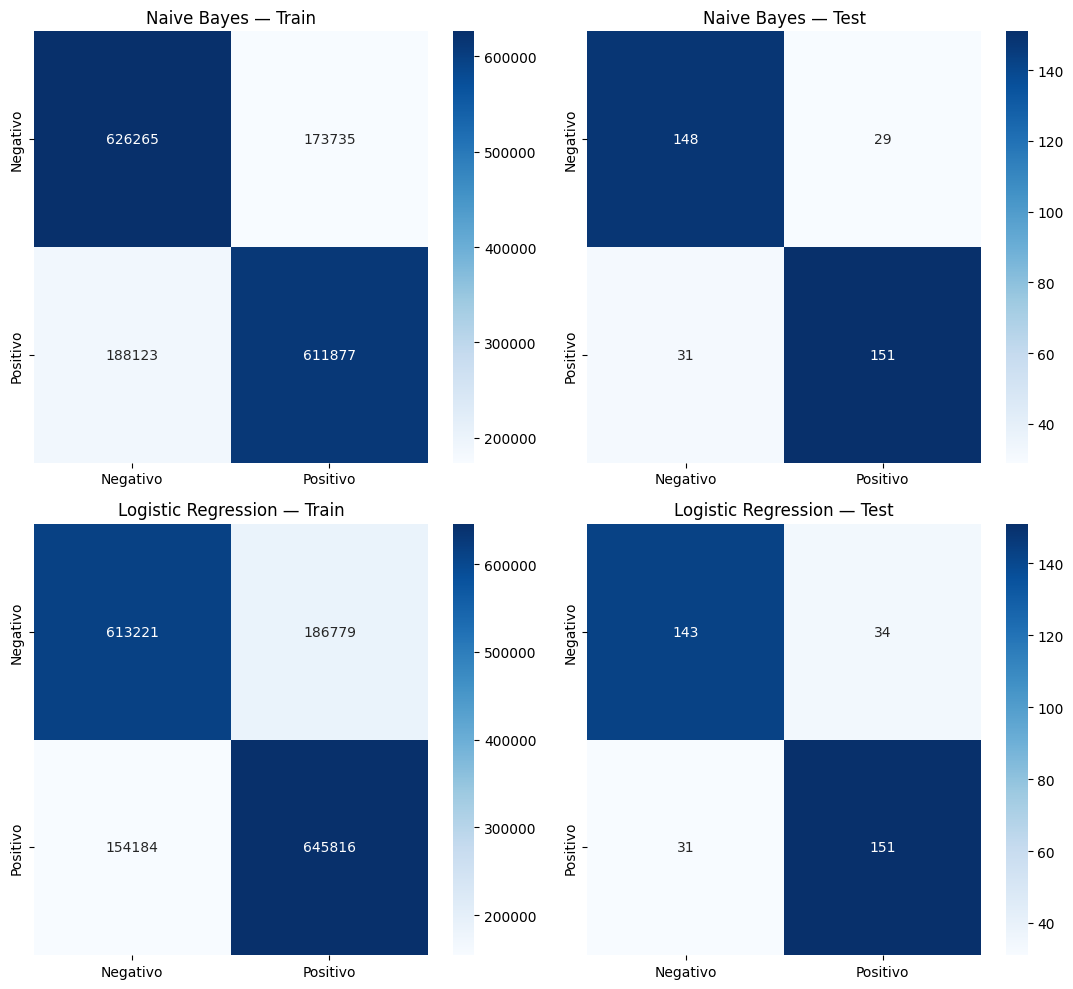

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

cm_nb_train = confusion_matrix(y_train, pred_nb_train, labels=[0,4])
sns.heatmap(cm_nb_train, annot=True, fmt="d", cmap="Blues", ax=axes[0,0],
            xticklabels=["Negativo","Positivo"], yticklabels=["Negativo","Positivo"])
axes[0,0].set_title("Naive Bayes — Train")

cm_nb_test = confusion_matrix(y_test_bin, pred_nb_bin, labels=[0,4])
sns.heatmap(cm_nb_test, annot=True, fmt="d", cmap="Blues", ax=axes[0,1],
            xticklabels=["Negativo","Positivo"], yticklabels=["Negativo","Positivo"])
axes[0,1].set_title("Naive Bayes — Test")

cm_lr_train = confusion_matrix(y_train, pred_lr_train, labels=[0,4])
sns.heatmap(cm_lr_train, annot=True, fmt="d", cmap="Blues", ax=axes[1,0],
            xticklabels=["Negativo","Positivo"], yticklabels=["Negativo","Positivo"])
axes[1,0].set_title("Logistic Regression — Train")

cm_lr_test = confusion_matrix(y_test_bin, pred_lr_bin, labels=[0,4])
sns.heatmap(cm_lr_test, annot=True, fmt="d", cmap="Blues", ax=axes[1,1],
            xticklabels=["Negativo","Positivo"], yticklabels=["Negativo","Positivo"])
axes[1,1].set_title("Logistic Regression — Test")

plt.tight_layout()
plt.show()

Las matrices completas muestran el patrón de comportamiento que distingue a los
dos modelos: LR recupera más positivos reales que NB en train (menos falsos
negativos: 154 mil vs 188 mil), pero a costa de más falsos positivos (187 mil vs
174 mil). En test se mantiene la tendencia: LR comete más falsos positivos (34 vs
29). NB es más conservador, LR más "generoso" prediciendo positivo — ninguno es
objetivamente mejor, es un trade-off que depende de qué error resulte más costoso
según el uso.

#### ROC-AUC (métrica adicional — respaldo directo del livecoding con RandomForest)

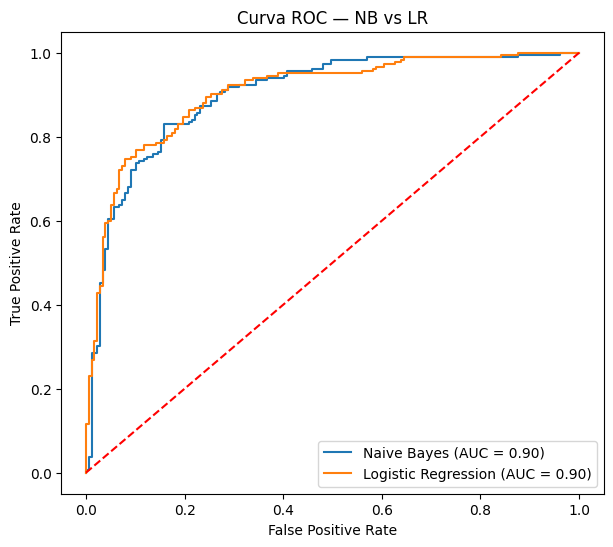

In [ ]:
proba_nb = modelo_nb.predict_proba(X_test_bow_bin)[:, 1]  # columna de la clase positiva (4)
proba_lr = modelo_lr.predict_proba(X_test_tfidf_bin)[:, 1]

roc_nb = roc_auc_score(y_test_bin, proba_nb)
roc_lr = roc_auc_score(y_test_bin, proba_lr)

fpr_nb, tpr_nb, _ = roc_curve(y_test_bin, proba_nb, pos_label=4)
fpr_lr, tpr_lr, _ = roc_curve(y_test_bin, proba_lr, pos_label=4)

plt.figure(figsize=(7,6))
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {roc_nb:.2f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_lr:.2f})")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — NB vs LR")
plt.legend(loc="lower right")
plt.show()

El AUC da prácticamente igual para los dos modelos (0.90 ambos), pese a que NB gana
en accuracy. La lectura: el AUC mide qué tan bien el modelo ordena los tweets de
más a menos positivo en todos los umbrales posibles, mientras que el accuracy usa
solo el corte de 0.5. Que empaten en AUC dice que ambos separan las clases igual de
bien en general — la pequeña ventaja de NB en accuracy viene de que el umbral por
defecto le queda mejor calibrado a este dataset.

#### TextBlob y la "zona gris": cuántos tweets binarios predijo como neutral

In [ ]:
n_hedged = (pred_textblob_bin == 2).sum()
pct_hedged = n_hedged / len(pred_textblob_bin) * 100

print(f"TextBlob predijo 'neutral' en {n_hedged} de {len(pred_textblob_bin)} tweets con etiqueta real binaria ({pct_hedged:.1f}%)")

TextBlob predijo 'neutral' en 61 de 359 tweets con etiqueta real binaria (17.0%)


La tabla confirma el orden final: NB (0.83) apenas arriba de LR (0.82), y TextBlob
bastante más abajo (0.64). Nótese que TextBlob mantiene precision alta (0.79) pese
a su accuracy bajo — la explicación está en la celda siguiente.

#### Similitud coseno — vecino más cercano de tweets mal clasificados (métrica obligatoria)

In [ ]:
mask_error_lr = pred_lr_bin != y_test_bin
indices_error = df_test_bin[mask_error_lr].index[:3]

for idx in indices_error:
    vector_tweet = X_test_tfidf_bin[idx]
    similitudes = X_train_tfidf.dot(vector_tweet.T).toarray().flatten()
    idx_vecino = similitudes.argmax()

    print("Tweet mal clasificado:", df_test_bin.loc[idx, "text"])
    print("  Real:", df_test_bin.loc[idx, "polarity"], "| Predicho LR:", pred_lr_bin[idx])
    print(f"Vecino más cercano en training (similitud coseno = {similitudes[idx_vecino]:.3f}):")
    print(" ", df_train.loc[idx_vecino, "text"], "| polaridad:", df_train.loc[idx_vecino, "polarity"])
    print("-" * 80)

Tweet mal clasificado: @kenburbary You'll love your Kindle2. I've had mine for a few months and never looked back. The new big one is huge! No need for remorse! :)
  Real: 4 | Predicho LR: 0
Vecino más cercano en training (similitud coseno = 0.413):
  I think the kindle DX is worse than the Kindle 2.  I love my Kindle 1 though. | polaridad: 0
--------------------------------------------------------------------------------
Tweet mal clasificado: #lebron best athlete of our generation, if not all time (basketball related) I don't want to get into inter-sport debates about   __1/2
  Real: 4 | Predicho LR: 0
Vecino más cercano en training (similitud coseno = 0.416):
  @bibendum_iwa The Appliance Generation ã?§ã?ã?­  | polaridad: 4
--------------------------------------------------------------------------------
Tweet mal clasificado: @Pmillzz lebron IS THE BOSS
  Real: 4 | Predicho LR: 0
Vecino más cercano en training (similitud coseno = 0.749):
  ...no more Lebron  | polaridad: 0
--------

#### Conclusiones

Naive Bayes (BoW) le ganó a Logistic Regression (TF-IDF): 0.83 vs 0.82, antes y
después de optimizar. Con tweets tan cortos (mediana 69 caracteres), TF-IDF no
tiene mucho margen para diferenciarse de un conteo simple.

Optimizar hiperparámetros (alpha=1.91, C=0.59) casi no movió el accuracy — con
1.6M de tweets balanceados, los modelos ya tenían de sobra para aprender bien.

El AUC dio igual para los dos (0.90), pese a que NB gana en accuracy. Ordenan
positivo/negativo casi igual de bien; el umbral por default le queda mejor
calibrado a NB.

Train vs test: accuracy mejor en test que en train en los dos modelos (no hay
overfitting) — probablemente porque el training se etiquetó automático por
emoticono (ruidoso) y el test lo etiquetó una persona a mano. Patrón que se
repite: LR agarra más positivos reales pero comete más falsos positivos que NB.

Contra TextBlob (0.64 vs nuestro 0.82-0.83): no está mal calibrado (precision
0.79), pero predijo "neutral" en ~1 de cada 5 tweets binarios — algo que NB/LR
no pueden hacer. TextBlob duda más, los nuestros no tienen esa opción.

Similitud coseno (métrica obligatoria): en 2 de 3 errores de LR analizados, el
problema fue el mismo — tweets con negación ("No need for remorse!", "...no more
Lebron") pierden el "not"/"no" al sacar stopwords, y el modelo se queda con
palabras sueltas que apuntan al sentimiento contrario. La optimización no lo
arregla: el LR optimizado se equivocó en los mismos 3 tweets — el problema es
del preprocesamiento, no del modelo.

Limitación central: training binario (0 y 4), test real con 3 clases (incluye
neutral). Los modelos no pueden predecir lo que nunca vieron, por eso evaluamos
sobre el subset binario; TextBlob sí maneja la tercera clase, y eso se analizó
aparte.